In [1]:
import StableDiffusion.ModelConverter
from StableDiffusion.DiffusionProcess import DiffusionProcess
device = 'cuda'
idleDevice = 'cpu'
filePath='../models/sd15models/v1-5-pruned-emaonly.ckpt'
diffusionDict = StableDiffusion.ModelConverter.load_from_standard_weights(input_file=filePath,\
                                                            device = 'cuda')
clipWeights=diffusionDict['clip']
diffusionWeights = diffusionDict['diffusion']
vaeEncoderWeights = diffusionDict['encoder']
vaeDecoderWeights = diffusionDict['decoder']

import torch
import StableDiffusion.ControlnetModelConverter
import importlib
importlib.reload(StableDiffusion.ControlnetModelConverter)
from StableDiffusion.ControlnetModelConverter import ControlnetModelConverter
filePath ="../models/ControlNet-v1-1/control_v11p_sd15_canny.pth" 
controlnetCannyDict  = torch.load(filePath, map_location= device)

import torch 
import StableDiffusion.VaeEncoder 
import StableDiffusion.VaeDecoder
import StableDiffusion.ClipEncoder
import StableDiffusion.DiffusionProcess
import importlib
importlib.reload(StableDiffusion.VaeEncoder)
importlib.reload(StableDiffusion.VaeDecoder)
importlib.reload(StableDiffusion.ClipEncoder)
importlib.reload(StableDiffusion.DiffusionProcess)
from StableDiffusion.VaeDecoder import VaeDecoder
from StableDiffusion.VaeEncoder import VaeEncoder
from StableDiffusion.ClipEncoder import ClipEncoder
from StableDiffusion.DiffusionProcess import DiffusionProcess
clipEncoder = ClipEncoder().to(device)
vaeEncoder = VaeEncoder().to(device)
vaeDecoder = VaeDecoder().to(device)
diffusionProcess = DiffusionProcess().to(device)
clipEncoder.load_state_dict(clipWeights,strict=True)
vaeEncoder.load_state_dict(vaeEncoderWeights ,strict=True)
vaeDecoder.load_state_dict(vaeDecoderWeights,strict=True)
diffusionProcess.load_state_dict(diffusionWeights,strict=True)



import StableDiffusion.ControlnetSD
import StableDiffusion.DiffusionProcessControlnet
importlib.reload(StableDiffusion.ControlnetSD)
importlib.reload(StableDiffusion.DiffusionProcessControlnet)
from StableDiffusion.ControlnetSD import ControlnetSD
from StableDiffusion.DiffusionProcessControlnet import DiffusionProcessControlnet


diffusionProcessControlnet = DiffusionProcessControlnet().to(device)
diffusionProcessControlnet.load_state_dict(diffusionWeights,strict=False)
#diffusionProcessControlnet.loadControlnetWeightsDict(controlWeightsDict =controlnetCannyDict)
diffusionProcessControlnet.loadControlnetWeightsDict(controlWeightsDict=None)

/home/aistudio/external-libraries/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
for name,param in diffusionProcessControlnet.controlnetOutput.named_parameters():
    print(name,param.shape,param.requires_grad)

unet.encoders.0.0.weight torch.Size([320, 4, 3, 3]) False
unet.encoders.0.0.bias torch.Size([320]) False
unet.encoders.1.0.groupnorm_feature.weight torch.Size([320]) False
unet.encoders.1.0.groupnorm_feature.bias torch.Size([320]) False
unet.encoders.1.0.conv_feature.weight torch.Size([320, 320, 3, 3]) False
unet.encoders.1.0.conv_feature.bias torch.Size([320]) False
unet.encoders.1.0.linear_time.weight torch.Size([320, 1280]) False
unet.encoders.1.0.linear_time.bias torch.Size([320]) False
unet.encoders.1.0.groupnorm_merged.weight torch.Size([320]) False
unet.encoders.1.0.groupnorm_merged.bias torch.Size([320]) False
unet.encoders.1.0.conv_merged.weight torch.Size([320, 320, 3, 3]) False
unet.encoders.1.0.conv_merged.bias torch.Size([320]) False
unet.encoders.1.1.groupnorm.weight torch.Size([320]) False
unet.encoders.1.1.groupnorm.bias torch.Size([320]) False
unet.encoders.1.1.conv_input.weight torch.Size([320, 320, 1, 1]) False
unet.encoders.1.1.conv_input.bias torch.Size([320]) Fals

torch.Size([1, 3, 512, 512])


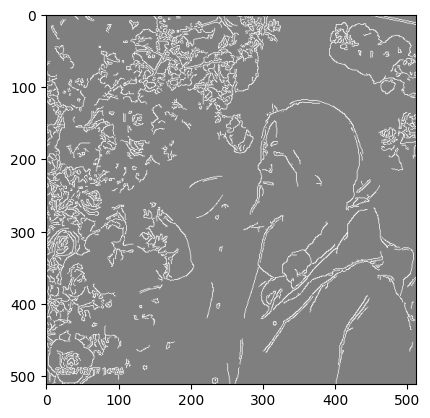

token embedding shape torch.Size([1, 77, 768])
token embedding shape torch.Size([1, 77, 768])
input image is none,use random noise instead


100%|██████████| 20/20 [00:03<00:00,  5.28it/s]


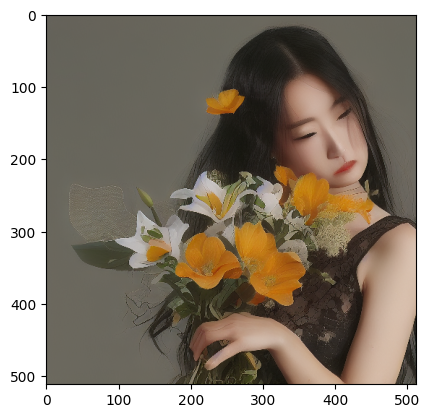

Epoch:   0%|          | 0/200 [00:00<?, ?it/s]

token embedding shape torch.Size([5, 77, 768])


token embedding shape torch.Size([5, 77, 768])


token embedding shape torch.Size([5, 77, 768])


token embedding shape torch.Size([5, 77, 768])


token embedding shape torch.Size([5, 77, 768])


100%|██████████| 5/5 [00:05<00:00,  1.06s/it]


token embedding shape torch.Size([1, 77, 768])
token embedding shape torch.Size([1, 77, 768])
input image is none,use random noise instead


100%|██████████| 20/20 [00:03<00:00,  5.31it/s]


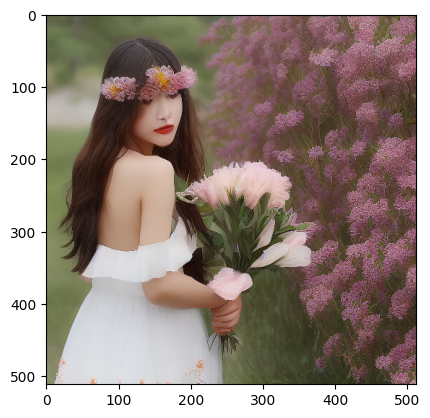

Epoch:   0%|          | 1/200 [00:09<31:55,  9.63s/it]

token embedding shape torch.Size([5, 77, 768])


token embedding shape torch.Size([5, 77, 768])


token embedding shape torch.Size([5, 77, 768])


token embedding shape torch.Size([5, 77, 768])


...

token embedding shape torch.Size([5, 77, 768])


token embedding shape torch.Size([5, 77, 768])


100%|██████████| 5/5 [00:05<00:00,  1.09s/it]


token embedding shape torch.Size([1, 77, 768])
token embedding shape torch.Size([1, 77, 768])
input image is none,use random noise instead


100%|██████████| 20/20 [00:03<00:00,  5.31it/s]


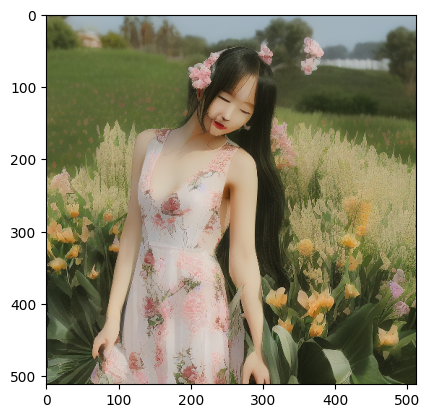

Epoch:   3%|▎         | 6/200 [00:41<23:16,  7.20s/it]

token embedding shape torch.Size([5, 77, 768])


token embedding shape torch.Size([5, 77, 768])


token embedding shape torch.Size([5, 77, 768])


token embedding shape torch.Size([5, 77, 768])


...

token embedding shape torch.Size([5, 77, 768])


token embedding shape torch.Size([5, 77, 768])


100%|██████████| 5/5 [00:05<00:00,  1.14s/it]


token embedding shape torch.Size([1, 77, 768])
token embedding shape torch.Size([1, 77, 768])
input image is none,use random noise instead


100%|██████████| 20/20 [00:03<00:00,  5.32it/s]


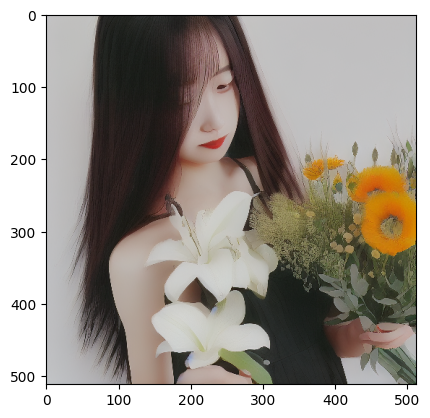

Epoch:   6%|▌         | 11/200 [01:13<22:24,  7.12s/it]

token embedding shape torch.Size([5, 77, 768])


token embedding shape torch.Size([5, 77, 768])


token embedding shape torch.Size([5, 77, 768])


In [3]:
import os
import cv2
import wandb
import torch
import numpy as np
import matplotlib.pyplot as plt 
import importlib
from tqdm import tqdm
from IPython import display
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# --- 1. Local StableDiffusion Module Imports ---
import StableDiffusion.Utils
import StableDiffusion.DdpmSamplerTorch
import StableDiffusion.LoraDataSet
import StableDiffusion.ControlnetDataSet
import StableDiffusion.LoraUtils
import StableDiffusion.ControlnetUtils
import StableDiffusion.GenPipe
import StableDiffusion.GenPipeControlnet
import StableDiffusion.CannyEdgeDetection
import StableDiffusion.VaeEncoder

# --- 2. Centralized Reload Logic ---
# Add any module here that you are actively editing
modules_to_reload = [
    StableDiffusion.Utils, StableDiffusion.DdpmSamplerTorch, 
    StableDiffusion.LoraDataSet, StableDiffusion.ControlnetDataSet,
    StableDiffusion.LoraUtils, StableDiffusion.ControlnetUtils,
    StableDiffusion.GenPipe, StableDiffusion.GenPipeControlnet,
    StableDiffusion.CannyEdgeDetection, StableDiffusion.VaeEncoder
]
for module in modules_to_reload:
    importlib.reload(module)

# --- 3. Explicit Class/Function Imports ---
from StableDiffusion.Utils import Utils
from StableDiffusion.DdpmSamplerTorch import DdpmSamplerTorch
from StableDiffusion.LoraDataSet import LoraDataSet
from StableDiffusion.ControlnetDataSet import ControlnetDataSet
from StableDiffusion.LoraUtils import *
from StableDiffusion.ControlnetUtils import ControlnetUtils
from StableDiffusion.GenPipe import GenPipe
from StableDiffusion.GenPipeControlnet import GenPipeControlnet
from StableDiffusion.CannyEdgeDetection import CannyEdgeDetection
from StableDiffusion.CannyToLatent import CannyToLatent
from StableDiffusion.ControlnetTimeEmbedding import ControlnetTimeEmbedding
from StableDiffusion.ZeroConvLayer import ZeroConvLayer
from StableDiffusion.VaeEncoder import VaeEncoder


filePath = './images/pusiyue_rose_1024_1024.jpg'
img = cv2.imread(filePath)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (512, 512))
cannyDetector = CannyEdgeDetection()
edgeImg = cannyDetector(img)
print(edgeImg.shape)
Utils.showBatchImage(edgeImg)
controlHint = edgeImg.to(device)
genPipeControlnet = GenPipeControlnet(vaeEncoder,vaeDecoder,clipEncoder,diffusionProcessControlnet)
genPipeControlnet.setControlHint(controlHint)
prompt ='1girl, solo, flower, long hair, \
    dress, bare shoulders, upper body, \
        realistic, lily \(flower\), black eyes, black hair, brown hair, holding flower, lips, sleeveless, \
    looking at viewer, holding, wind, closed mouth, bouquet, blue dress'
promptNegative ='low quality, worst quality, blurry, out of focus, \
    jpeg artifacts, watermark,\
        text, logo, signature, oversharpened, \
            overexposed, underexposed, bad anatomy, \
                bad proportions, deformed, distorted, \
                    disfigured, mutated, extra limbs, extra arms,\
                        extra legs, extra fingers, fused fingers,\
                            missing fingers, long neck, cross-eyed, \
                                bad eyes, plastic skin, doll-like, cgi, 3d render'
GenNum=1
for i in range(GenNum):
    genPipeControlnet.seed = np.random.randint(10000)
    genPipeControlnet.numInferenceSteps =20
    imgStepList = genPipeControlnet.genImage(prompt,promptNegative)




os.environ["WANDB_API_KEY"] = "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"

wandb.login()
savePath ='/home/aistudio/wandb'
wandb.init(
    entity="42998474-anyang",
    project='sd15-controlnet-training',
    config={
        'image nums':25,
        'epoch num':5,
        'learning rate':1e-4,
        'batch size':5,
        
    },
    dir = savePath
)



device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
sampler = DdpmSamplerTorch()
sampler.to(device)
controlnetDataSet = ControlnetDataSet()
controlnetDataLoader = DataLoader(controlnetDataSet,batch_size=5,
                                shuffle=True,num_workers=0,drop_last=True,collate_fn=None)
vaeEncoder.eval()
vaeDecoder.eval()
clipEncoder.eval()
diffusionProcessControlnet.train()

trainableParamsDict = {}
for name,param in diffusionProcessControlnet.named_parameters():
    if param.requires_grad:
        #print(name,param.shape)
        trainableParamsDict[name]=param


# for name,param in trainableParamsDict.items():
#     print(name,param.shape)
    
lossHistory = []
epochLossHistory = []

optimizer = torch.optim.Adam(trainableParamsDict.values(), lr=1e-4)
EpochNum = 200
for epoch in tqdm(range(EpochNum),desc='Epoch'):
    epochLoss = 0.0
    for i,data in enumerate(tqdm(controlnetDataLoader)):
        img,controlHint,promptTokens,attentionMask = data
        with torch.no_grad():
            latentImg = vaeEncoder(img)        
        with torch.no_grad():
            clipOutputsPositive = clipEncoder(promptTokens,attentionMask)       
        BatchSize,Channel,Height,Width = latentImg.shape
        noiseLatent = torch.randn(BatchSize,Channel,Height,Width,dtype=torch.float32,device=device)
        timeSteps =torch.randint(0,1000,(BatchSize,),device=device)        
        latentImgNoised = sampler.addNoiseBatchTrain(latentImg,noiseLatent,timeSteps)        
        predictedNoise= diffusionProcessControlnet(latentImgNoised,clipOutputsPositive,timeSteps,controlHint)
        with torch.no_grad():        
            noisedImg =vaeDecoder(latentImgNoised)
            
        loss = nn.functional.mse_loss(predictedNoise,noiseLatent)
        
        lossHistory.append(loss.item())
        epochLoss = epochLoss + loss.item()
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    epochLoss = epochLoss / len(controlnetDataLoader)
    epochLossHistory.append(epochLoss)  
    if epoch % 5==0:
        GenNum=1
        for i in range(GenNum):
            genPipeControlnet.seed = np.random.randint(10000)
            genPipeControlnet.numInferenceSteps =20
            imgStepList = genPipeControlnet.genImage(prompt,promptNegative)
            imgBatch = imgStepList[-1]
            testControlImg = Utils.getBatchImage(imgBatch)        
            wandb.log({ 'epoch/test control image':wandb.Image(testControlImg,caption=f'controlnet_{epoch}')})
    
    wandb.log({'epoch/loss': epochLoss,
               'epoch/iter': epoch              
               })          


wandb.finish()

ControlnetUtils.writeControlnetToFile(diffusionProcessControlnet)



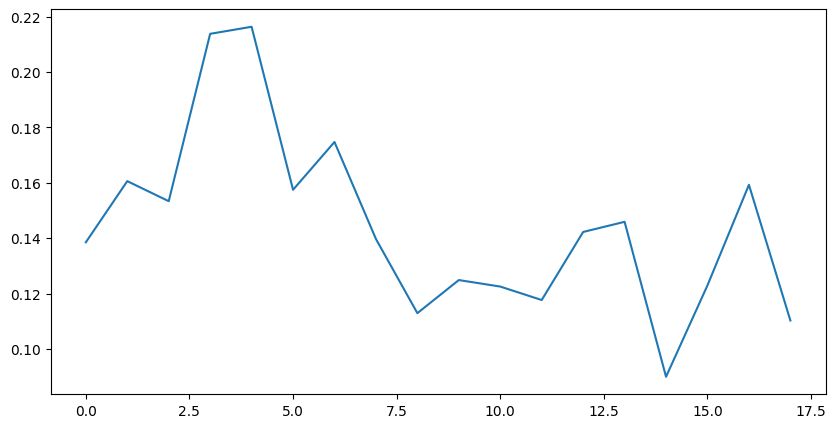

Epoch:  18%|█▊        | 18/100 [02:10<10:15,  7.51s/it]

token embedding shape torch.Size([5, 77, 768])


epoch: 18, iter: 0, loss:0.18181617558002472
token embedding shape torch.Size([5, 77, 768])


Epoch:  18%|█▊        | 18/100 [02:12<10:05,  7.38s/it]


KeyboardInterrupt: 

In [22]:
import os
import cv2
import wandb
import torch
import numpy as np
import importlib
import matplotlib.pyplot as plt 
from tqdm import tqdm
from IPython import display
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# --- Local StableDiffusion Modules ---
import StableDiffusion.LoraDataSet
import StableDiffusion.DdpmSamplerTorch
import StableDiffusion.Utils
import StableDiffusion.LoraUtils
import StableDiffusion.GenPipe
import StableDiffusion.GenPipeControlnet
import StableDiffusion.CannyEdgeDetection

# Reload everything once
for module in [
    StableDiffusion.DdpmSamplerTorch, StableDiffusion.LoraDataSet, 
    StableDiffusion.Utils, StableDiffusion.LoraUtils, 
    StableDiffusion.GenPipe, StableDiffusion.GenPipeControlnet,
    StableDiffusion.CannyEdgeDetection
]:
    importlib.reload(module)

# Explicit Class Imports
from StableDiffusion.Utils import Utils
from StableDiffusion.DdpmSamplerTorch import DdpmSamplerTorch
from StableDiffusion.LoraDataSet import LoraDataSet
from StableDiffusion.LoraUtils import *
from StableDiffusion.GenPipe import GenPipe
from StableDiffusion.GenPipeControlnet import GenPipeControlnet
from StableDiffusion.CannyEdgeDetection import CannyEdgeDetection
from StableDiffusion.CannyToLatent import CannyToLatent
from StableDiffusion.ControlnetTimeEmbedding import ControlnetTimeEmbedding
from StableDiffusion.ZeroConvLayer import ZeroConvLayer




wandb.init(
    project='xiaofeixiang lora training ',
    config={
        'image nums':25,
        'epoch num':5,
        'learning rate':1e-4,
        'batch size':5,
        
    }
)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
sampler = DdpmSamplerTorch()
sampler.to(device)
loraDataSet = LoraDataSet()
loraDataLoader = DataLoader(loraDataSet,batch_size=5,
                                shuffle=True,num_workers=0,drop_last=True,collate_fn=None)
# batchsize = 10 is almost the biggest batchsize
loraDataSet.__len__()
img,promtTokens,attentionMask = loraDataSet[0]
print(img.shape,promtTokens.shape,attentionMask.shape)

vaeEncoder.eval()
vaeDecoder.eval()
clipEncoder.eval()
diffusionProcess.train()

trainableParamsList = []
for name,param in diffusionProcess.named_parameters():
    if param.requires_grad:
        #print(name,param.shape)
        trainableParamsList.append(param)  


lossHistory = []
epochLossHistory = []



optimizer = torch.optim.Adam(trainableParamsList, lr=1e-4)
EpochNum = 100
for epoch in tqdm(range(EpochNum),desc='Epoch'):
    epochLoss = 0.0
    for i,data in enumerate(tqdm(loraDataLoader)):
        img,promptTokens,attentionMask = data
        with torch.no_grad():
            latentImg = vaeEncoder(img)
        
        with torch.no_grad():
            clipOutputsPositive = clipEncoder(promptTokens,attentionMask)
        
        
        BatchSize,Channel,Height,Width = latentImg.shape

        noiseLatent = torch.randn(BatchSize,Channel,Height,Width,dtype=torch.float32,device=device)
        timeSteps =torch.randint(0,1000,(BatchSize,),device=device)
        #print(timeSteps.shape,timeSteps)
        latentImgNoised = sampler.addNoiseBatchTrain(latentImg,noiseLatent,timeSteps)
        timeEmb320 =Utils.getTimeEmbeddingBatch(timeSteps)
        timeEmb320 = sampler.numpy2Tensor(timeEmb320)
        #print(latentImgNoised.shape,clipOutputsPositive.shape,timeEmb320.shape)
        predictedNoise= diffusionProcess(latentImgNoised,clipOutputsPositive,timeEmb320)
        with torch.no_grad():        
            noisedImg =vaeDecoder(latentImgNoised)
            
        loss = nn.functional.mse_loss(predictedNoise,noiseLatent)
        
        lossHistory.append(loss.item())
        epochLoss = epochLoss + loss.item()
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        print(f'epoch: {epoch}, iter: {i}, loss:{loss.item()}')
        
            
        #Utils.showBatchImage(img[:1])
        #Utils.showBatchImage(latentImg[:1,:3])
        #Utils.showBatchImage(noisedImg[:1])
    epochLoss = epochLoss / len(loraDataLoader)
    epochLossHistory.append(epochLoss)
    
    genPipe = GenPipe(vaeEncoder,vaeDecoder,clipEncoder,diffusionProcess)
    prompt = 'xiaofeixiang,1girl'
    prompt ='xiaofeixiang,1girl, solo, flower, long hair, \
    dress, bare shoulders, upper body, \
        realistic, lily \(flower\), black eyes, black hair, brown hair, holding flower, lips, sleeveless, \
    looking at viewer, holding, wind, closed mouth, bouquet, blue dress'
    promptNegative ='low quality, worst quality, blurry, out of focus, \
        jpeg artifacts, watermark,\
            text, logo, signature, oversharpened, \
                overexposed, underexposed, bad anatomy, \
                    bad proportions, deformed, distorted, \
                        disfigured, mutated, extra limbs, extra arms,\
                            extra legs, extra fingers, fused fingers,\
                                missing fingers, long neck, cross-eyed, \
                                    bad eyes, plastic skin, doll-like, cgi, 3d render'

        
          
    print(f'epoch: {epoch}, epochLoss:{epochLoss}')
    wandb.log({'epoch/loss': epochLoss,
               'epoch/iter': epoch,
               #'epoch/test lora image':wandb.Image(testLoraImg,caption=f'test lora {epoch}')
               })
    
    if epoch % 5 ==0:
        GenNum=1
        for i in range(GenNum):
            genPipe.seed = np.random.randint(10000)
            genPipe.numInferenceSteps =20
            imgStepList = genPipe.genImage(prompt,promptNegative)
            imgBatch = imgStepList[-1]
            testLoraImg = Utils.getBatchImage(imgBatch)
        
        wandb.log({'epoch/test lora image':wandb.Image(testLoraImg,caption=f'test lora {epoch}')})    
    display.clear_output(wait=True)
    plt.figure(figsize= (10,5))
    plt.plot(epochLossHistory,label='epoch loss')    
    display.display(plt.gcf())
    plt.close()
           
writeLoraToFile(diffusionProcess)

wandb.finish()
        